In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [3]:
df = pd.read_csv("C:\\Users\\bingi\\Downloads\\healthcare_appointment_no_show_wait_time.csv")
df.head()

,appointment_id,appointment_date,patient_age,gender,department,appointment_type,scheduled_hour,waiting_time_minutes,reminder_sent,previous_no_shows,appointment_status
0,1,2024-01-01 00:00:00,52,Female,Orthopedics,New,12,82,Yes,4,Completed
1,2,2024-01-01 01:00:00,15,Female,Cardiology,Follow-up,9,176,No,2,No-Show
2,3,2024-01-01 02:00:00,72,Female,Orthopedics,New,13,100,Yes,2,Completed
3,4,2024-01-01 03:00:00,61,Female,Orthopedics,New,14,54,No,4,Completed
4,5,2024-01-01 04:00:00,21,Male,Pediatrics,New,8,121,Yes,3,Completed


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   appointment_id        2800 non-null   int64 
 1   appointment_date      2800 non-null   object
 2   patient_age           2800 non-null   int64 
 3   gender                2800 non-null   object
 4   department            2800 non-null   object
 5   appointment_type      2800 non-null   object
 6   scheduled_hour        2800 non-null   int64 
 7   waiting_time_minutes  2800 non-null   int64 
 8   reminder_sent         2800 non-null   object
 9   previous_no_shows     2800 non-null   int64 
 10  appointment_status    2800 non-null   object
dtypes: int64(5), object(6)
memory usage: 240.8+ KB


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2800
Number of columns: 11


In [6]:
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

In [7]:
df.isnull().sum()

appointment_id          0
appointment_date        0
patient_age             0
gender                  0
department              0
appointment_type        0
scheduled_hour          0
waiting_time_minutes    0
reminder_sent           0
previous_no_shows       0
appointment_status      0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
gender_percent = df['gender'].value_counts(normalize = True).round(2) * 100
gender_percent = gender_percent.apply(lambda x : f"{x:.1f}%")
gender_percent

gender
Male      51.0%
Female    49.0%
Name: proportion, dtype: object

In [10]:
dept_percent = (df['department'].value_counts(normalize = True).round(2) * 100)
dept_percent = dept_percent.apply(lambda x : f'{x:.1f}%')
dept_percent

department
Cardiology          21.0%
Pediatrics          20.0%
Dermatology         20.0%
Orthopedics         19.0%
General Medicine    19.0%
Name: proportion, dtype: object

In [11]:
appointment_percent = (df['appointment_type'].value_counts(normalize = True).round(2) * 100)
appointment_percent = appointment_percent.apply(lambda x : f'{x:.1f}%')
appointment_percent

appointment_type
Follow-up    50.0%
New          50.0%
Name: proportion, dtype: object

In [12]:
df['appointment_id'].nunique()

2800

In [13]:
appointment_month = df['appointment_date'].dt.month_name()
appointment_month_counts = appointment_month.value_counts()

fig = px.bar(
    x=appointment_month_counts.index,
    y=appointment_month_counts.values,
    labels={'x':'Month', 'y':'Appointments'},
    title='Number of Appointments by Month',
    color=appointment_month_counts.index 
)
fig.show()


In [14]:
appointment_date = df['appointment_date'].dt.date
appointment_date_counts = appointment_date.value_counts().reset_index()
appointment_date_counts.columns = ['index', 'appointment_date']

fig = px.line(appointment_date_counts,
    x = appointment_date_counts['index'],
    y = appointment_date_counts['appointment_date'],
    labels={'x':'Date', 'y':'Appointments'},
    title = 'Number of Appointments by Date'
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()



In [15]:
patient_age_counts = df['patient_age'].value_counts().reset_index()
patient_age_counts.columns = ['index', 'patient_age']
fig = px.bar(patient_age_counts,
    x = patient_age_counts['index'],
    y = patient_age_counts['patient_age'],
    labels={'x':'Age', 'y':'Appointments'},
    title = 'Number of Appointments by Age'
)
fig.show()

In [16]:
scheduled_hour_counts = df['scheduled_hour'].value_counts().reset_index()
scheduled_hour_counts.columns = ['index', 'scheduled_hour']
fig = px.bar(scheduled_hour_counts,
             x = scheduled_hour_counts['index'],
             y = scheduled_hour_counts['scheduled_hour'],
             labels={'x':'Scheduled Hour', 'y':'Appointments'},
             title = 'Number of Appointments by Scheduled Hour'
)
fig.show()

                        0
Valid         2800.000000
Missing          0.000000
Mean            90.189286
Std Dev         50.522952
Min              5.000000
25%             46.750000
50% (Median)    88.000000
75%            133.000000
Max            179.000000


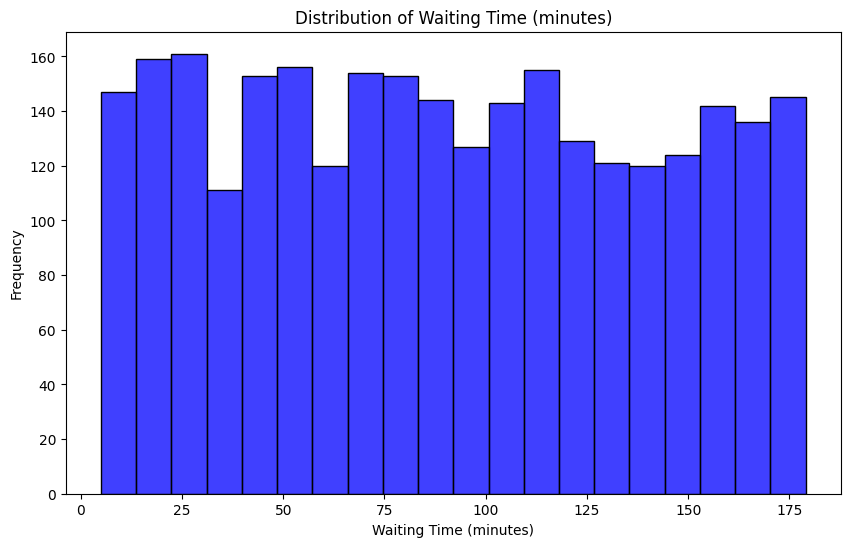

In [19]:

# Example column: waiting_time_minutes
waiting_time = df['waiting_time_minutes']

# --- Summary statistics ---
summary = {
    "Valid": waiting_time.count(),
    "Missing": waiting_time.isna().sum(),
    "Mean": waiting_time.mean(),
    "Std Dev": waiting_time.std(),
    "Min": waiting_time.min(),
    "25%": waiting_time.quantile(0.25),
    "50% (Median)": waiting_time.median(),
    "75%": waiting_time.quantile(0.75),
    "Max": waiting_time.max()
}

summary_df = pd.DataFrame(summary, index=[0])
print(summary_df.T)  

# --- Histogram plot ---
plt.figure(figsize=(10,6))
sns.histplot(waiting_time, bins=20, color='blue', kde=False)

plt.title('Distribution of Waiting Time (minutes)')
plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Frequency')
plt.show()


                        0
Valid         2800.000000
Missing          0.000000
Mean            13.575357
std_dev          3.451087
Min              8.000000
25%             11.000000
50% (Median)    14.000000
75%             17.000000
Max             19.000000


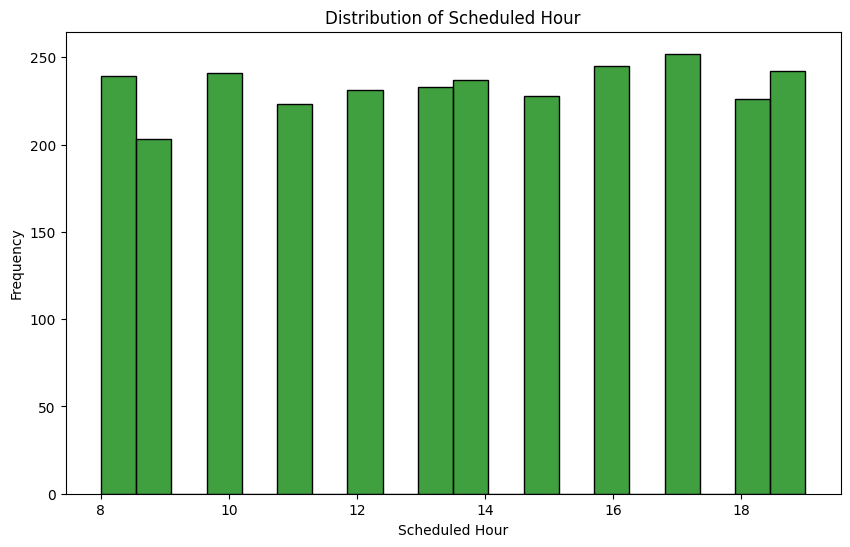

In [ ]:
scheduled_hour = df['scheduled_hour']

summary = {
    'Valid' : scheduled_hour.count(),
    'Missing' : scheduled_hour.isnull().sum(),
    'Mean' : scheduled_hour.mean(),
    'std_dev' : scheduled_hour.std(),
    'Min' : scheduled_hour.min(),
    '25%' : scheduled_hour.quantile(0.25),
    '50% (Median)' : scheduled_hour.median(),
    '75%' : scheduled_hour.quantile(0.75),
    'Max' : scheduled_hour.max()
}
summary_df = pd.DataFrame(summary, index=[0])
print(summary_df.T)
plt.figure(figsize=(10,6))
sns.histplot(scheduled_hour, bins=20, color='green', kde=False)
plt.title('Distribution of Scheduled Hour')
plt.xlabel('Scheduled Hour')
plt.ylabel('Frequency')
plt.show()


In [ ]:
reminder = df['reminder_sent']

summary = {
    "Valid": reminder.count(),
    "Mismatched": 0,   # if you have validation rules, adjust here
    "Missing": reminder.isna().sum()
}
summary_df = pd.DataFrame(summary, index=[0])
print(summary_df.T)

remnder_sent = df['reminder_sent'].value_counts()

fig = px.pie(
    values = remnder_sent.values,
    names = remnder_sent.index,
    title = 'Distribution of Reminder Sent',
    hole = 0.4
)

fig.update_traces(textposition='inside', textinfo='percent+label+value')
fig.show()

               0
Valid       2800
Mismatched     0
Missing        0


In [ ]:
reminder_gender = (
    df.groupby(['reminder_sent', 'gender'])['appointment_id']
      .count()
      .reset_index()
)

reminder_gender['label'] = reminder_gender['reminder_sent'].astype(str) + " " + reminder_gender['gender']

fig = px.pie(
    reminder_gender,
    values='appointment_id',
    names='label',
    title='Count of appointment_id and %GT Count of gender by reminder_sent and gender',
    hole=0.4
)

fig.update_traces(textposition='inside', textinfo='label+percent+value')
fig.show()


In [ ]:
previous_no_show = df['previous_no_shows']

summary = {
    "Valid": previous_no_show.count(),
    "Mismatched": 0, 
    "Missing": previous_no_show.isna().sum().round(2),
    'Mean': previous_no_show.mean().round(2),
    'Std Dev': previous_no_show.std().round(2),
    'min': previous_no_show.min().round(2),
    '25%': previous_no_show.quantile(0.25).round(2),
    '50% (Median)': previous_no_show.median().round(2),
    '75%': previous_no_show.quantile(0.75).round(2),
    'Max': previous_no_show.max().round(2) 
}

summary_df = pd.DataFrame(summary, index=[0])
print(summary_df.T)

previous_no_show_counts = df['previous_no_shows'].value_counts().reset_index()
previous_no_show_counts.columns = ['Previous No Shows', 'Appointments']

fig = px.bar(
    previous_no_show_counts,
    x='Previous No Shows',
    y='Appointments',
    labels={'Previous No Shows': 'Previous No Shows', 'Appointments': 'Number of Appointments'},
    title='Number of Appointments by Previous No Shows',
    color='Previous No Shows' 
)

fig.show()

                    0
Valid         2800.00
Mismatched       0.00
Missing          0.00
Mean             1.99
Std Dev          1.41
min              0.00
25%              1.00
50% (Median)     2.00
75%              3.00
Max              4.00


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Cardiology'),
  Text(1, 0, 'Dermatology'),
  Text(2, 0, 'General Medicine'),
  Text(3, 0, 'Orthopedics'),
  Text(4, 0, 'Pediatrics')])

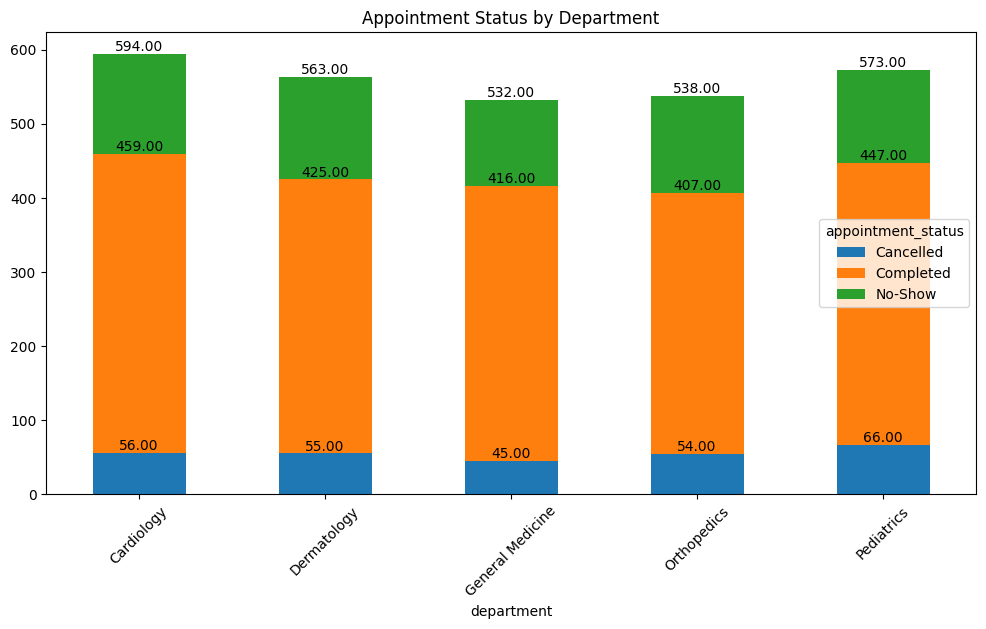

In [ ]:
department_appointment_status = df.groupby('department')['appointment_status'].value_counts().unstack().fillna(0)
ax = department_appointment_status.plot(kind='bar', stacked=True, figsize=(12,6))
for container in ax.containers:
    ax.bar_label(container , fmt = '%.2f')
plt.title('Appointment Status by Department')
plt.xticks(rotation = 45)

C:\Users\bingi\AppData\Local\Temp\ipykernel_30688\3190206805.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


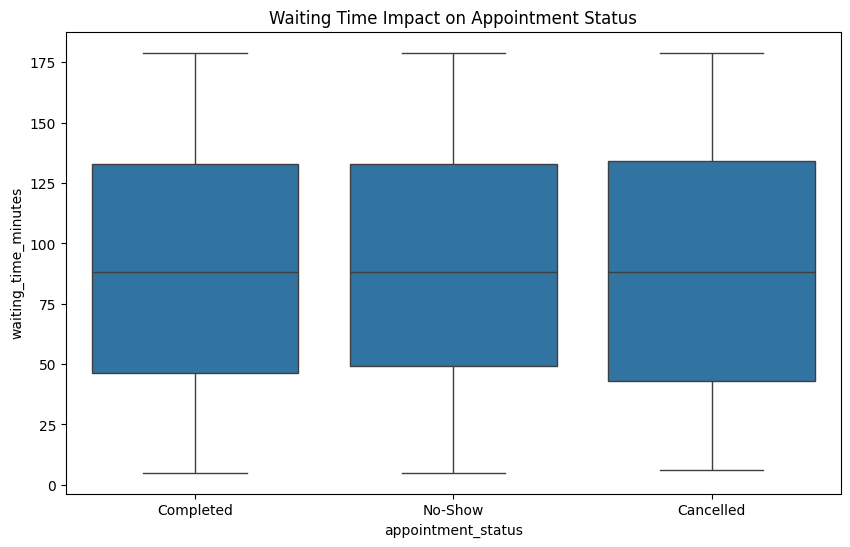

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='appointment_status', y='waiting_time_minutes')
plt.title('Waiting Time Impact on Appointment Status')
fig.show()


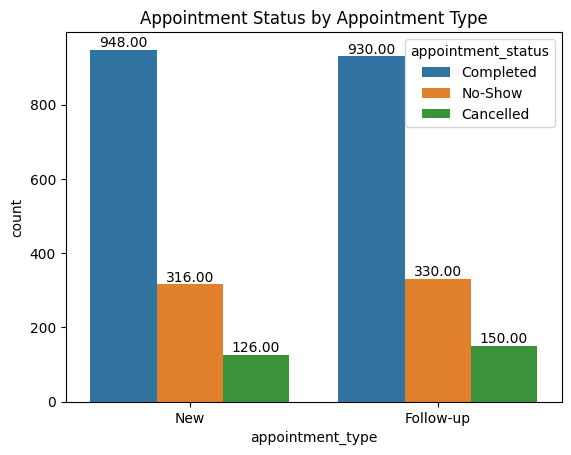

In [20]:
plt.Figure(figsize=(10,6))
ax = sns.countplot(data=df, x='appointment_type' , hue = 'appointment_status')

for container in ax.containers:
    ax.bar_label(container , fmt = '%.2f')

plt.title('Appointment Status by Appointment Type')
plt.show()

In [ ]:
fig = pd.pivot_table(df,
                     index = 'department',
                     columns = 'appointment_status',
                     values = 'appointment_id',
                     aggfunc = 'count')
fig

appointment_status,Cancelled,Completed,No-Show
department,,,
Cardiology,56,403,135
Dermatology,55,370,138
General Medicine,45,371,116
Orthopedics,54,353,131
Pediatrics,66,381,126


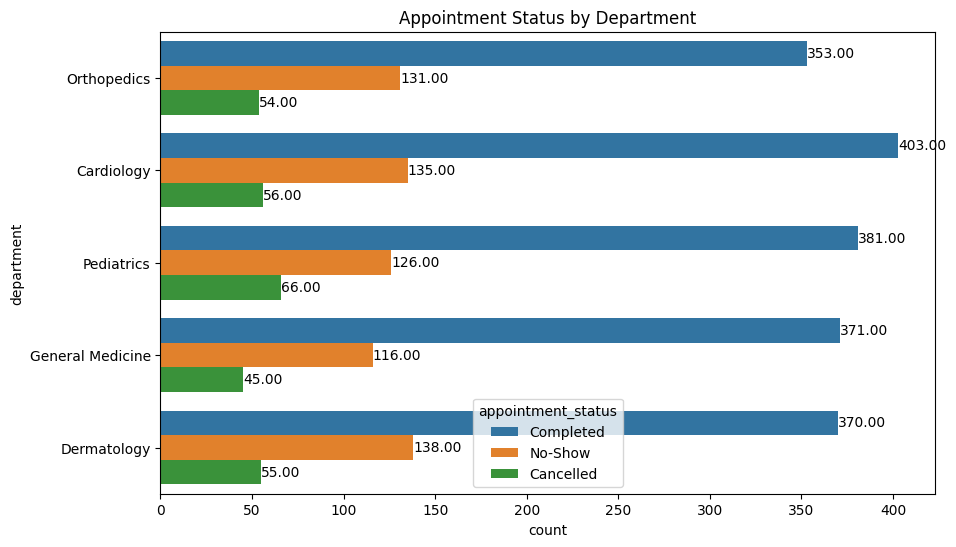

In [ ]:
fig = plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, y='department', hue='appointment_status' , legend = True)

for container in ax.containers:
    ax.bar_label(container , fmt = '%.2f')

plt.title('Appointment Status by Department')
plt.show()

In [ ]:
appointment_status_by_gender = df.groupby('gender')['appointment_status'].value_counts().reset_index()
appointment_status_by_gender

,gender,appointment_status,count
0,Female,Completed,914
1,Female,No-Show,312
2,Female,Cancelled,136
3,Male,Completed,964
4,Male,No-Show,334
5,Male,Cancelled,140


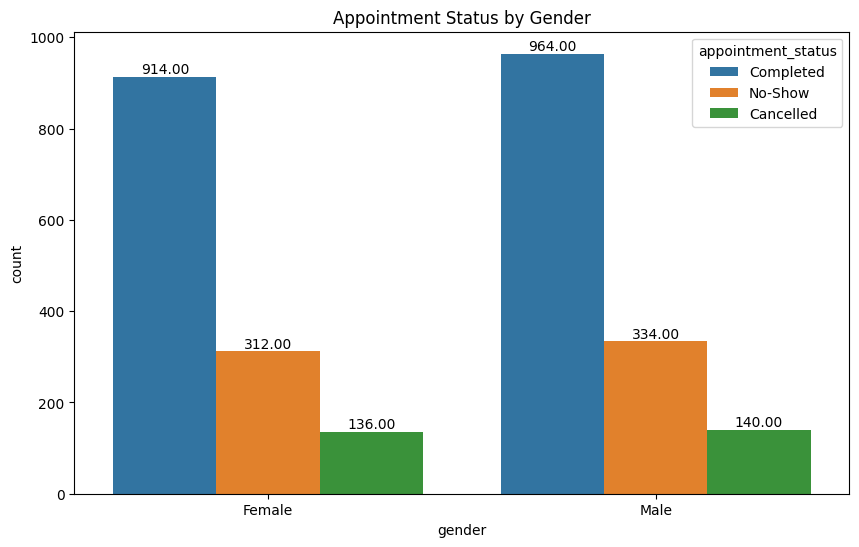

In [ ]:
fig = plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, x='gender', hue='appointment_status')

for container in ax.containers:
    ax.bar_label(container , fmt = '%.2f')
    
plt.title('Appointment Status by Gender')
plt.show()

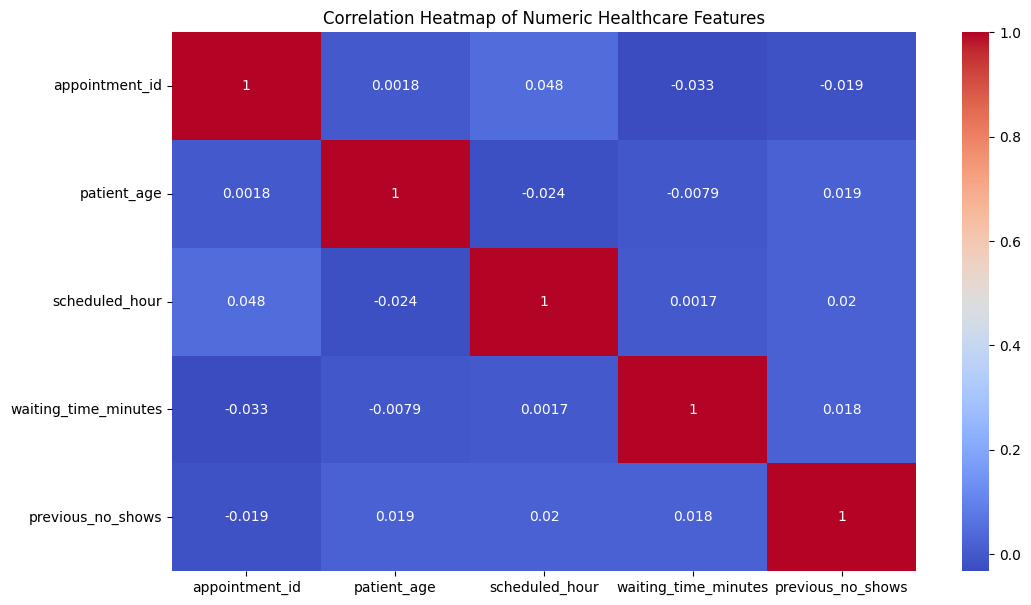

In [ ]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(12, 7))
sns.heatmap(corr , annot = True , cmap = 'coolwarm')
plt.title("Correlation Heatmap of Numeric Healthcare Features")
plt.show()